# Time-resolved noise-correlation PSTHs, split by trial condition
For each time bin (sliding window), the mean within-region pairwise spike-count correlation across trials of a condition level. Shown for an example session split by contrast / side / choice / outcome / block, then averaged across sessions with brain-region selection.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from scipy.ndimage import uniform_filter1d
from iblatlas.regions import BrainRegions
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trial_meta_path = prefix + '4_mice/session_trial_meta_03-07-2026'

REGION_LEVEL = 'beryl'    # 'cosmos' | 'beryl' - beryl so grouped regions (e.g. VISUAL_AREAS)
                          # average distinct-area curves within a session, rather than
                          # pooling all their neurons into one correlation matrix
DROP = ['root', 'void']
DROP = [ 'void']
WIN_BINS = 5              # sliding-window width (bins) for the spike-count correlation
MIN_NEURONS = 15           # per region in a session
MIN_LEVEL_TRIALS = 15      # min trials per condition level
SPLIT_VARS = ['contrast', 'side', 'choice', 'feedback', 'block']
SMOOTH_MODE = 'causal'     # 'causal' (uses only bins <= t; no future leakage) or 'centered'
BALANCE_LEVELS = False      # subsample each condition level to equal #trials
SEED = 0
SPLIT_VARS = ['contrast', 'feedback', 'block_congruent']
GOCUE_TOL = 0.01           # seconds - tolerance for validating trial_id alignment against ONE
N_EXCLUDE_POST_SWITCH = 5  # trials right after a block switch to exclude from block_congruent
                           # (bias not yet behaviorally reflected / block identity itself is
                           # ambiguous to the animal in this window)

# Visual cortex Beryl areas - pass as `regions=VISUAL_AREAS` to plot_grid to average their
# already-separately-computed curves within a session (not pooled into one correlation
# matrix - within-area pairs are typically far more correlated than cross-area pairs, so
# pooling neurons first would conflate the two). VISC is excluded: despite the "VIS" prefix
# it's visceral (interoceptive) cortex in the Allen atlas, not visual.
VISUAL_AREAS = ['VISp', 'VISa', 'VISam', 'VISal', 'VISl', 'VISli', 'VISpl', 'VISpm', 'VISpor', 'VISrl']

# Trial behavior (choice/feedback/block) fetched live from ONE and precomputed by
# precompute_session_trial_meta.ipynb, replacing the deprecated-pipeline all_trials_04-05-2026
# (which silently dropped every no-go trial - see notebook history). side/contrast are NOT
# duplicated here since firing_rate_computation.ipynb already derives them correctly from
# contrastLeft/contrastRight via ONE (stored in each pid file's 'condition' column).
session_trial_meta = pd.read_parquet(trial_meta_path)
trial_beh = {s: g.set_index('trial_id')[['choice', 'feedback', 'block', 'goCueTrigger_times']]
             for s, g in session_trial_meta.groupby('session')}
br = BrainRegions()
print("params set")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/4_mice/session_trial_meta_03-07-2026'

## Compute noise-correlation PSTHs per session x region x condition level

In [ ]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols])
T = len(tcols)

def rsc_curve(A):
    """A: neurons x trials x T (windowed rates). Mean off-diagonal correlation per time bin."""
    nN, nL, Tn = A.shape
    if nL < 3 or nN < 2: return np.full(Tn, np.nan)
    mean = np.nanmean(A, axis=1, keepdims=True)
    std = np.nanstd(A, axis=1, ddof=1, keepdims=True)
    Z = (A - mean) / std
    Z[~np.isfinite(Z)] = np.nan
    s = np.nansum(Z, axis=0)                       # trials x T
    sumsq = np.nansum(s ** 2, axis=0)              # T
    nvalid = ((np.isfinite(std[:, 0, :])) & (std[:, 0, :] > 0)).sum(0).astype(float)
    with np.errstate(invalid='ignore', divide='ignore'):
        off = (sumsq / (nL - 1) - nvalid) / (nvalid * (nvalid - 1))
    off[nvalid < 2] = np.nan
    return off

def smooth_time(A, W, mode):
    """Moving average of width W along the time axis (axis=2)."""
    if mode == 'centered':
        return uniform_filter1d(A, W, axis=2, mode='nearest')
    # causal: trailing mean using only bins <= t (expanding window for the first W bins)
    c = np.cumsum(A, axis=2)
    out = np.empty_like(A)
    out[..., :W] = c[..., :W] / np.arange(1, W + 1)
    out[..., W:] = (c[..., W:] - c[..., :-W]) / W
    return out

def trials_since_block_switch(block_series):
    """block_series: full-session 'block' (probabilityLeft) indexed by trial_id, in
    chronological order. Returns, per trial_id, how many trials have elapsed since the
    block last changed (0 = first trial of a new block)."""
    is_switch = block_series.ne(block_series.shift())
    if len(is_switch): is_switch.iloc[0] = True
    run_id = is_switch.cumsum()
    return block_series.groupby(run_id).cumcount()

rng = np.random.default_rng(SEED)
records = []
n_session_mismatch = 0
n_congruent, n_incongruent, n_neutral_block, n_excluded_post_switch = 0, 0, 0, 0
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        beh = trial_beh.get(session)
        if beh is None: continue
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)

        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}

        # Validate the trial_id join against ONE before trusting any of beh's columns:
        # compare this file's own per-trial event_time (goCueTrigger_times, saved by
        # firing_rate_computation.ipynb) against ONE's goCueTrigger_times at the same
        # trial_id. Any mismatch means trial_id doesn't mean what we assume for this
        # session, so skip it rather than silently mislabeling trials.
        own_event_time = d.drop_duplicates('trial_id').set_index('trial_id')['event_time'].reindex(trials)
        one_event_time = beh['goCueTrigger_times'].reindex(trials)
        mismatch = (own_event_time - one_event_time).abs() > GOCUE_TOL
        if mismatch.any():
            n_session_mismatch += 1
            print(f"  Skipping session {session}: {int(mismatch.sum())}/{len(trials)} trial_id "
                  f"mismatches vs ONE (goCueTrigger_times)")
            continue

        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values

        # per-neuron region (optionally Cosmos)
        na = d.groupby('nuid')['area'].first().reindex(neurons)
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values

        # trial metadata: side/contrast from this file's own (ONE-derived) condition column;
        # choice/feedback/block from the ONE-fetched session_trial_meta, already validated above
        cond = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials)
        meta = pd.DataFrame(index=trials)
        meta['side'] = cond.str.split('_').str[0].values
        meta['contrast'] = cond.str.split('_').str[1].astype(float).values
        meta['choice'] = beh['choice'].reindex(trials).values
        meta['feedback'] = beh['feedback'].reindex(trials).values
        meta['block'] = beh['block'].reindex(trials).values

        # Block congruence: does the stimulus side match the block's favored side?
        # block is probabilityLeft: >0.5 -> Left-favored block, <0.5 -> Right-favored block,
        # ==0.5 -> neutral block with no favored side (left as real NaN, excluded like any
        # other split var's missing level via vals.dropna() below).
        # NOTE: build favored_side via boolean-mask assignment, NOT np.where(cond, 'Left',
        # np.where(cond2, 'Right', np.nan)) - mixing string branches with np.nan in nested
        # np.where coerces nan into the *literal string* "nan" (object-dtype upcast), which
        # .isna() does NOT detect, silently routing every neutral-block trial into
        # 'incongruent' instead of excluding it. Confirmed and fixed after the block
        # congruence stats looked off (incongruent was ~36% instead of the expected ~20%).
        favored_side = pd.Series(index=meta.index, dtype=object)
        favored_side[meta['block'] > 0.5] = 'Left'
        favored_side[meta['block'] < 0.5] = 'Right'

        meta['block_congruent'] = pd.Series(index=meta.index, dtype=object)
        valid_block = favored_side.notna()
        meta.loc[valid_block & (meta['side'] == favored_side), 'block_congruent'] = 'congruent'
        meta.loc[valid_block & (meta['side'] != favored_side), 'block_congruent'] = 'incongruent'

        # Exclude the first N_EXCLUDE_POST_SWITCH trials of each block: computed on the full
        # session's chronological block sequence (beh, indexed 0..n_session_trials-1), not
        # just the trials present in this pid file, so a gap in this file's trial_id set
        # can't be mistaken for "start of a new block".
        since_switch = trials_since_block_switch(beh['block']).reindex(trials)
        post_switch = since_switch < N_EXCLUDE_POST_SWITCH
        n_excluded_post_switch += int((post_switch & meta['block_congruent'].notna()).sum())
        meta.loc[post_switch, 'block_congruent'] = np.nan

        n_congruent += int((meta['block_congruent'] == 'congruent').sum())
        n_incongruent += int((meta['block_congruent'] == 'incongruent').sum())
        n_neutral_block += int(favored_side.isna().sum())

        for region in pd.unique(neu_area):
            if region is None or (isinstance(region, float) and np.isnan(region)): continue
            ni = np.where(neu_area == region)[0]
            if len(ni) < MIN_NEURONS: continue
            Asub = A[ni]
            complete = ~np.isnan(Asub).any(axis=(0, 2))
            if complete.sum() < MIN_LEVEL_TRIALS: continue
            Aw = smooth_time(Asub[:, complete, :], WIN_BINS, SMOOTH_MODE)
            cmeta = meta.iloc[np.where(complete)[0]]
            for var in SPLIT_VARS:
                vals = cmeta[var]
                levels = [lv for lv in vals.dropna().unique() if (vals == lv).sum() >= MIN_LEVEL_TRIALS]
                if len(levels) < 2:
                    continue
                n_target = min((vals == lv).sum() for lv in levels) if BALANCE_LEVELS else None
                for level in levels:
                    idx = np.where((vals == level).values)[0]
                    if BALANCE_LEVELS:
                        idx = rng.choice(idx, n_target, replace=False)
                    records.append(dict(session=session, region=region, var=var, level=level,
                                        n_neurons=len(ni), n_trials=int(len(idx)),
                                        curve=rsc_curve(Aw[:, idx, :])))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

curves = pd.DataFrame(records)
print(f"Computed {len(curves)} curves | {curves['session'].nunique()} sessions | "
      f"regions: {sorted(curves['region'].unique())}")
if n_session_mismatch:
    print(f"{n_session_mismatch} pid files skipped due to trial_id/goCueTrigger_times mismatch vs ONE")

n_total_block_trials = n_congruent + n_incongruent + n_neutral_block + n_excluded_post_switch
print(f"\nBlock congruence trial counts (across all pid files, before per-region/session filtering):")
print(f"  congruent:              {n_congruent} ({100*n_congruent/max(n_total_block_trials,1):.1f}%)")
print(f"  incongruent:            {n_incongruent} ({100*n_incongruent/max(n_total_block_trials,1):.1f}%)")
print(f"  excluded (post-switch): {n_excluded_post_switch} ({100*n_excluded_post_switch/max(n_total_block_trials,1):.1f}%)")
print(f"  excluded (neutral block, probabilityLeft==0.5): {n_neutral_block} ({100*n_neutral_block/max(n_total_block_trials,1):.1f}%)")

  100/374 files...
  200/374 files...
  300/374 files...
Computed 9122 curves | 228 sessions | regions: ['ACAd', 'ACAv', 'ACB', 'AId', 'AIp', 'AIv', 'AM', 'ANcr1', 'ANcr2', 'AON', 'APN', 'AV', 'BLA', 'BST', 'CA1', 'CA3', 'CEA', 'CENT2', 'CENT3', 'CL', 'CLA', 'COAa', 'COPY', 'CP', 'CS', 'CUL4 5', 'CUN', 'DCO', 'DEC', 'DG', 'DN', 'DP', 'DTN', 'ECT', 'ENTl', 'ENTm', 'EPd', 'EPv', 'Eth', 'FL', 'FN', 'FOTU', 'FRP', 'FS', 'GPe', 'GPi', 'GRN', 'HATA', 'IC', 'ICB', 'ILA', 'IP', 'IRN', 'LA', 'LAV', 'LD', 'LDT', 'LGd', 'LGv', 'LHA', 'LP', 'LPO', 'LSc', 'LSr', 'LSv', 'MARN', 'MD', 'MDRN', 'MEA', 'MG', 'MOB', 'MOp', 'MOs', 'MPO', 'MRN', 'MS', 'MV', 'NB', 'NDB', 'NI', 'NLL', 'NOD', 'NPC', 'NTS', 'ORBl', 'ORBm', 'ORBvl', 'OT', 'PAA', 'PAG', 'PAR', 'PARN', 'PB', 'PCG', 'PCN', 'PF', 'PFL', 'PGRN', 'PIR', 'PL', 'PO', 'POL', 'POST', 'PPN', 'PRE', 'PRM', 'PRNc', 'PRNr', 'PRP', 'PS', 'PSV', 'PVT', 'PYR', 'PoT', 'ProS', 'RN', 'RSPagl', 'RSPd', 'RSPv', 'RT', 'SAG', 'SCm', 'SCs', 'SF', 'SGN', 'SI', 'SIM', 'S

## Plot helpers

In [ ]:
def _order_levels(var, levels):
    if var in ('contrast', 'block'):
        return sorted(levels, key=lambda x: float(x))
    return sorted(levels, key=str)

def _agg(df_sub):
    """-> dict level -> (sessions x T) matrix (region-averaged within session)."""
    out = {}
    for level, g in df_sub.groupby('level'):
        per_sess = g.groupby('session')['curve'].apply(lambda cs: np.nanmean(np.vstack(cs.values), axis=0))
        out[level] = np.vstack(per_sess.values)
    return out

def plot_grid(df, session=None, regions=None, title=''):
    d = df.copy()
    if session is not None: d = d[d['session'] == session]
    if regions is not None: d = d[d['region'].isin(regions)]
    vars_present = [v for v in SPLIT_VARS if v in d['var'].unique()]
    fig, axes = plt.subplots(1, len(vars_present), figsize=(4.2 * len(vars_present), 4.2), squeeze=False)
    for k, var in enumerate(vars_present):
        ax = axes[0][k]
        agg = _agg(d[d['var'] == var])
        levels = _order_levels(var, list(agg.keys()))
        cmap = plt.cm.viridis(np.linspace(0, 1, len(levels))) if var in ('contrast', 'block')                else plt.cm.tab10(np.linspace(0, 1, len(levels)))
        for c, level in zip(cmap, levels):
            M = agg[level]; mean = np.nanmean(M, axis=0)
            ax.plot(tsec, mean, color=c, lw=2, label=f'{level} (N={M.shape[0]})')
            if M.shape[0] > 1:
                sem = np.nanstd(M, axis=0) / np.sqrt(M.shape[0])
                ax.fill_between(tsec, mean - sem, mean + sem, color=c, alpha=0.15)
        ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1.2)
        ax.set_xlabel('Time (s)'); ax.set_ylabel('mean r_SC'); ax.set_title(var, fontsize=11)
        ax.set_xlim([-0.3, 0.6]); ax.legend(fontsize=7); sns.despine(ax=ax, offset=4)
    fig.suptitle(title, y=1.03, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## Example session

Example session: 4ecb5d24-f5cc-402c-be28-9d0f7cb14b3a  (regions: ['BST', 'FRP', 'LPO', 'LSr', 'LSv', 'MOB', 'NDB', 'PS', 'root'])


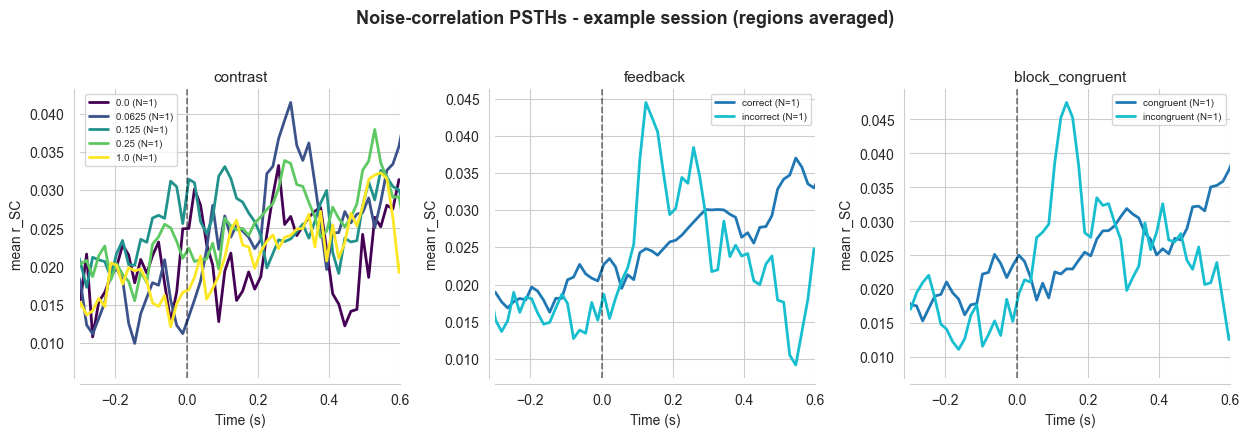

In [ ]:
# pick the session with the most neuron-mass as the example
ex = (curves.groupby('session')['n_neurons'].sum().idxmax())
print(f"Example session: {ex}  (regions: {sorted(curves[curves.session==ex]['region'].unique())})")
plot_grid(curves, session=ex, title=f'Noise-correlation PSTHs - example session (regions averaged)')

## Averaged across sessions (select regions or all)

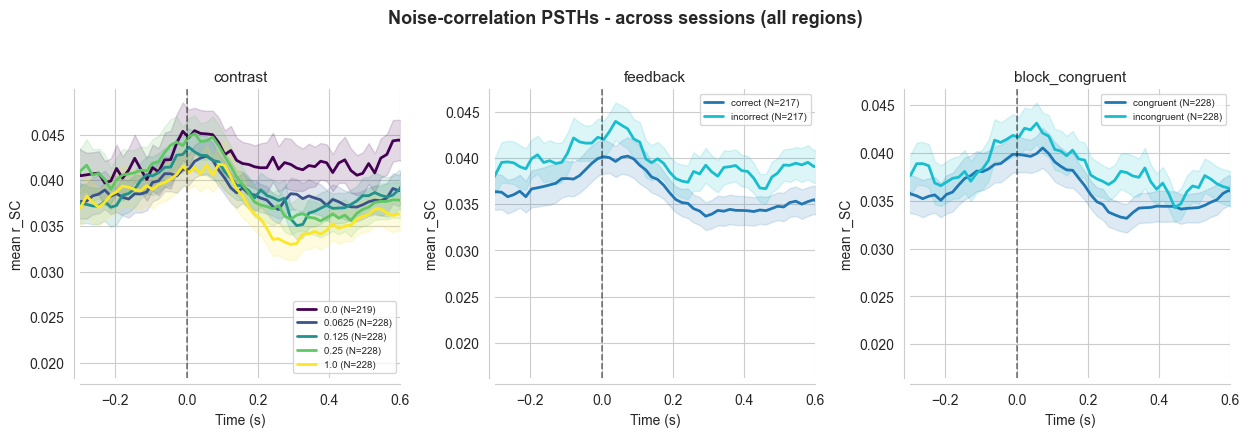

In [ ]:
# REGIONS = None -> average across all regions; or a list e.g. ['Isocortex'] / ['TH','HPF']
REGIONS = VISUAL_AREAS
REGIONS = ['CA1']
REGIONS = None
plot_grid(curves, regions=REGIONS,
          title=f'Noise-correlation PSTHs - across sessions ({"all regions" if REGIONS is None else REGIONS})')

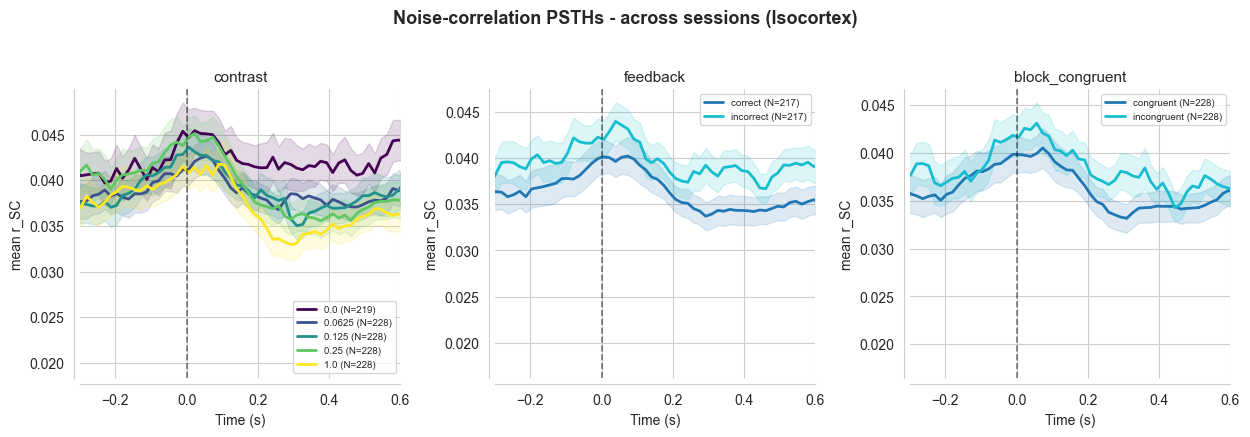

In [ ]:
# example with a specific region
plot_grid(curves, regions=REGIONS,
          title='Noise-correlation PSTHs - across sessions (Isocortex)')